In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv(Path("../") / "Results" / "perf_benchmark.csv")
df

,subject,dataset,model,epoch_window,accuracy
0,1,Dreyer2023,Deep4Net,w_00_40,0.80625
1,1,Lee2019_MI,Deep4Net,w_00_30,0.63000
2,2,Lee2019_MI,Deep4Net,w_00_30,0.61000
3,3,Lee2019_MI,Deep4Net,w_00_30,0.85000
4,4,Lee2019_MI,Deep4Net,w_00_30,0.76000
...,...,...,...,...,...
273,84,Dreyer2023,Deep4Net,w_05_45,0.74375
274,85,Dreyer2023,Deep4Net,w_05_45,0.63125
275,86,Dreyer2023,Deep4Net,w_05_45,0.63750
276,87,Dreyer2023,Deep4Net,w_05_45,0.79375


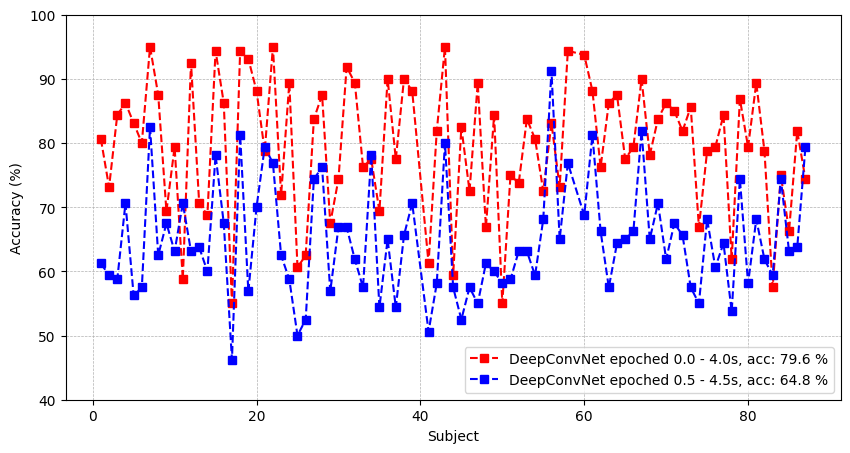

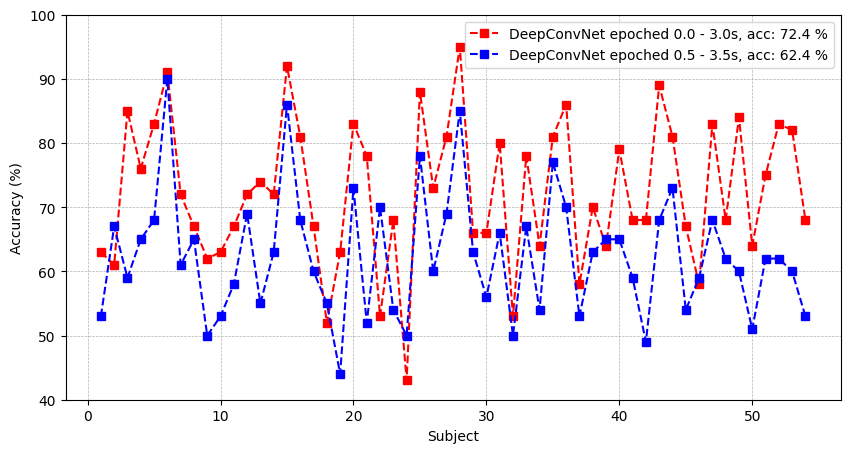

In [16]:
def win_name(window):
    t1 = window.split("_")[1]
    t2 = window.split("_")[2]
    t1 = f"{t1[0]}.{t1[1]}"
    t2 = f"{t2[0]}.{t2[1]}"

    return float(t1), float(t2)


def plot_accuracy(df, dataset, model, windows=["w_00_40", "w_05_45"], colors=["red", "blue"], ax=None):
    if ax is None:
        _, ax = plt.subplots()

    df = df[(df["dataset"] == dataset) & (df["model"] == model)]

    for window, color in zip(windows, colors):
        df_window = df[df["epoch_window"] == window]

        df_window = df_window.sort_values("subject")
        mean_acc = df_window["accuracy"].mean()

        t1, t2 = win_name(window)

        if model == "Deep4Net":
            model_name = "DeepConvNet"

        ax.plot(df_window["subject"], df_window["accuracy"] * 100, marker="s", linestyle="--",
                label=f"{model_name} epoched {t1} - {t2}s, acc: {mean_acc * 100:.1f} %"
                , color=color)

    ax.set_ylim([40, 100])
    ax.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Subject")


fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023", model="Deep4Net", ax=ax)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Lee2019_MI", model="Deep4Net", windows=["w_00_30", "w_05_35"], ax=ax)
